In [1]:
import os
import sys
from pathlib import Path


print('cwd:        ', os.getcwd())
print('python:     ', sys.executable)

cwd:         c:\Users\kedha\Documents\dfw-hospital-pricing\notebooks
python:      c:\Users\kedha\Documents\dfw-hospital-pricing\venv\Scripts\python.exe


In [2]:
import os
print(os.getcwd())

c:\Users\kedha\Documents\dfw-hospital-pricing\notebooks


In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src.queries import classify_plan, add_lob, query_procedure_rates_agg, LOB_PATTERNS
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


In [4]:
import duckdb
import pandas as pd
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

RAW = Path('../data/raw')

hospitals = {
    'baylor':                RAW / 'baylor_university_medical_center-69947_parsed.duckdb',
    'methodist':             RAW / 'methodist_dallas_medical_center-6000b_parsed.duckdb',
    'parkland':              RAW / 'parkland_health-6e88d_parsed.duckdb',
    'texas_health_plano':    RAW / 'texas_health_presbyterian_hospital_plano-6ad81_parsed.duckdb',
    'medical_city_alliance': RAW / 'medical_city_alliance_hospital-77912_parsed.duckdb',
}

for name, path in hospitals.items():
    print(f"{name:25s} {'OK' if path.exists() else 'MISSING'}  {path.name}")

cons = {name: duckdb.connect(str(path), read_only=True) for name, path in hospitals.items()}

print(f"\nOpened {len(cons)} connections.")

baylor                    OK  baylor_university_medical_center-69947_parsed.duckdb
methodist                 OK  methodist_dallas_medical_center-6000b_parsed.duckdb
parkland                  OK  parkland_health-6e88d_parsed.duckdb
texas_health_plano        OK  texas_health_presbyterian_hospital_plano-6ad81_parsed.duckdb
medical_city_alliance     OK  medical_city_alliance_hospital-77912_parsed.duckdb

Opened 5 connections.


In [5]:





print("Aggregated row counts (one per payer/plan/methodology/billing_class combo):\n")
for name, con in cons.items():
    df = query_procedure_rates_agg(con, '73721')
    n_combos_with_dollar_variation = (df['dollar_min'] != df['dollar_max']).sum()
    print(f"  {name:25s} {len(df):4d} combos   ({n_combos_with_dollar_variation} with varying dollar across charge_ids)")

Aggregated row counts (one per payer/plan/methodology/billing_class combo):

  baylor                      45 combos   (0 with varying dollar across charge_ids)
  methodist                   82 combos   (0 with varying dollar across charge_ids)
  parkland                    65 combos   (44 with varying dollar across charge_ids)
  texas_health_plano          40 combos   (5 with varying dollar across charge_ids)
  medical_city_alliance       46 combos   (16 with varying dollar across charge_ids)


In [6]:
print(f"dfs type: {type(dfs)}")
print(f"dfs contents: {dfs}")

NameError: name 'dfs' is not defined

In [ ]:
CODE = '73721'
SETTING = 'outpatient'

dfs = {}
for name, con in cons.items():
    raw = query_procedure_rates_agg(con, CODE, SETTING)
    classified = add_lob(raw)
    dfs[name] = classified
    print(f'{name:25s} {len(classified):>4d} combos')

print(f"\ndfs keys: {list(dfs.keys())}")
print(f"columns: {list(dfs['methodist'].columns)}")

baylor                      45 combos
methodist                   82 combos
parkland                    65 combos
texas_health_plano          40 combos
medical_city_alliance       46 combos

dfs keys: ['baylor', 'methodist', 'parkland', 'texas_health_plano', 'medical_city_alliance']
columns: ['payer_name', 'plan_name', 'payer_group', 'payer_type', 'methodology_normalized', 'billing_class_normalized', 'n_charge_ids', 'dollar_rate', 'dollar_min', 'dollar_max', 'pct_rate', 'gross_min', 'gross_max', 'descriptions', 'lob', 'lob_rule']


In [ ]:
for c in dfs['methodist'].columns:
    print(c)

payer_name
plan_name
payer_group
payer_type
methodology_normalized
billing_class_normalized
n_charge_ids
dollar_rate
dollar_min
dollar_max
pct_rate
gross_min
gross_max
descriptions
lob
lob_rule


In [ ]:
print("LOB distribution per hospital (combo counts):\n")
lob_counts = pd.DataFrame({
    h: dfs[h]['lob'].value_counts()
    for h in dfs.keys()
}).fillna(0).astype(int)
print(lob_counts.to_string())

print("\n\nLOB distribution per hospital (% of combos):\n")
lob_pct = pd.DataFrame({
    h: dfs[h]['lob'].value_counts(normalize=True).mul(100).round(1)
    for h in dfs.keys()
}).fillna(0)
print(lob_pct.to_string())

print("\n\nCommercial-only combo counts per hospital:")
for h in dfs.keys():
    n_comm = (dfs[h]['lob'] == 'commercial').sum()
    n_total = len(dfs[h])
    n_unknown = (dfs[h]['lob'] == 'unknown').sum()
    print(f"  {h:25s} commercial={n_comm:>3d}  unknown={n_unknown:>3d}  total={n_total:>3d}")

LOB distribution per hospital (combo counts):

                      baylor  methodist  parkland  texas_health_plano  medical_city_alliance
lob                                                                                         
aca_exchange               1          3         2                   1                      1
commercial                12          6         3                   5                      2
medicaid_chip              1          0        17                   0                      5
medicaid_other             1          0         9                   0                      0
medicaid_star              0          1         8                   0                      3
medicaid_star_plus         0          3         3                   0                      1
medicare_advantage         8          1         7                   0                      0
medicare_traditional       3         22         0                  22                      0
unknown                

In [ ]:
for h in dfs.keys():
    unk = dfs[h][dfs[h]['lob'] == 'unknown']
    print(f"\n=== {h} — {len(unk)} unknown combos ===")
    print(unk['payer_name'].value_counts().head(10).to_string())


=== baylor — 19 unknown combos ===
payer_name
Baylor Scott & White Health Plan    5
Blue Cross Blue Shield              3
HealthSmart                         2
United Healthcare                   2
PHCS                                1
TriWest                             1
Prime Health Services               1
QuickTrip                           1
Texas Workforce Commission          1
Cigna                               1

=== methodist — 46 unknown combos ===
payer_name
BCBS [3001]                              5
AETNA MANAGED CARE [2068]                3
AETNA COMMERCIAL [2042]                  2
WEB TPA [3049]                           2
AETNA [3000]                             2
90 DEGREE BENEFIT [3057]                 1
GENERIC WORKERS COMP TX PAR [8002]       1
PROVIDER PARTNERS HEALTH PLAN [7025]     1
VELOCITY [3070]                          1
WELLPOINT MARKETPLACE EXCHANGE [3071]    1

=== parkland — 16 unknown combos ===
payer_name
BLUE CROSS BLUE SHIELD [1012]             3


In [ ]:
from pathlib import Path
Path('../outputs').mkdir(exist_ok=True)
print('outputs/ ready')

outputs/ ready


## Chart 1 — Commercial dollar rates by hospital (CPT 73721)

**Read this before the chart.**

This chart shows median commercial negotiated dollar rates for knee MRI without contrast, by hospital, using the v1 LOB classifier built on Day 5. It is preliminary. The dominant signal in the chart is classifier coverage, not rate variation across hospitals.

### What the chart actually shows

Bars are sorted by median commercial dollar rate, ascending top-to-bottom. Bar color encodes sample size — not anything about the hospital:

- **Blue (n ≥ 5):** bar = median, error bars = interquartile range
- **Orange (n < 5):** bar = median, thin black line = min/max range

Right-side annotations show the commercial sample size (`n`) and the share of all combos at that hospital that fell into the v1 classifier's `unknown` bucket.

### Caveats baked into the data

1. **Three of five bars are based on fewer than 5 data points.** Parkland (n=2), Medical City Alliance (n=1), and Texas Health Plano (n=4) should not be read as representative of their hospital's commercial book. Methodist (n=6) is borderline. Only Baylor (n=12) has enough commercial combos for the median to mean much.

2. **The `unknown` bucket is doing most of the work.** Medical City Alliance has 74% of its combos in `unknown` — meaning v1 can't classify three out of four MCA payer/plan combinations. Methodist is 56%, Baylor 42%. Day 5's v1 classifier matches explicit LOB keywords (CHIP, STAR, Medicare Advantage, Commercial, PPO/HMO/EPO) but most commercial plans at private hospitals are sold under payer brand names with no LOB marker in the plan name string. Parkland is the exception (25% unknown) because it's a public safety-net hospital whose plan names spell out Medicaid programs explicitly.

3. **Methodist's commercial range starts at $232.47.** That is the standard Medicare allowable for CPT 73721. At least one Methodist combo classified as "commercial" by v1 is almost certainly Medicare under a confusingly-named plan. Day 7 v2 classifier should add rate-value pattern matching (~$232.47 → Medicare, ~$208.80 → Texas Medicaid) to catch these.

4. **Parkland's $4,368 median appears as a dramatic outlier.** It is the same dollar rate appearing twice — both combos negotiated to the same value, not a confirmed pattern. Worth investigating in Day 7 work but should not be quoted as Parkland's commercial rate.

5. **Within-combo dollar variation is hidden.** Day 5 established that 68% of Parkland combos and 35% of Medical City Alliance combos have dollar rates that vary across underlying chargemaster `charge_id` rows within a single combo. The `query_procedure_rates_agg` median collapses that variation. Hospitals with low charge_id fanout (Methodist, Baylor) are unaffected by this collapse.

### What this chart is good for

- **Day 6 sanity check:** confirms the pipeline runs end-to-end against fresh source data and reproduces Day 5's combo counts.
- **Motivating v2 classifier work:** the `unknown` bucket percentages quantify how much volume v1 is missing.
- **Establishing Baylor as the only currently-trustworthy commercial cohort** for cross-hospital comparison at v1.

### What this chart is NOT

- A reliable cross-hospital commercial rate comparison
- A basis for any external claim about who pays what
- A finished deliverable — comes back in revised form on Day 7+ after v2 classifier

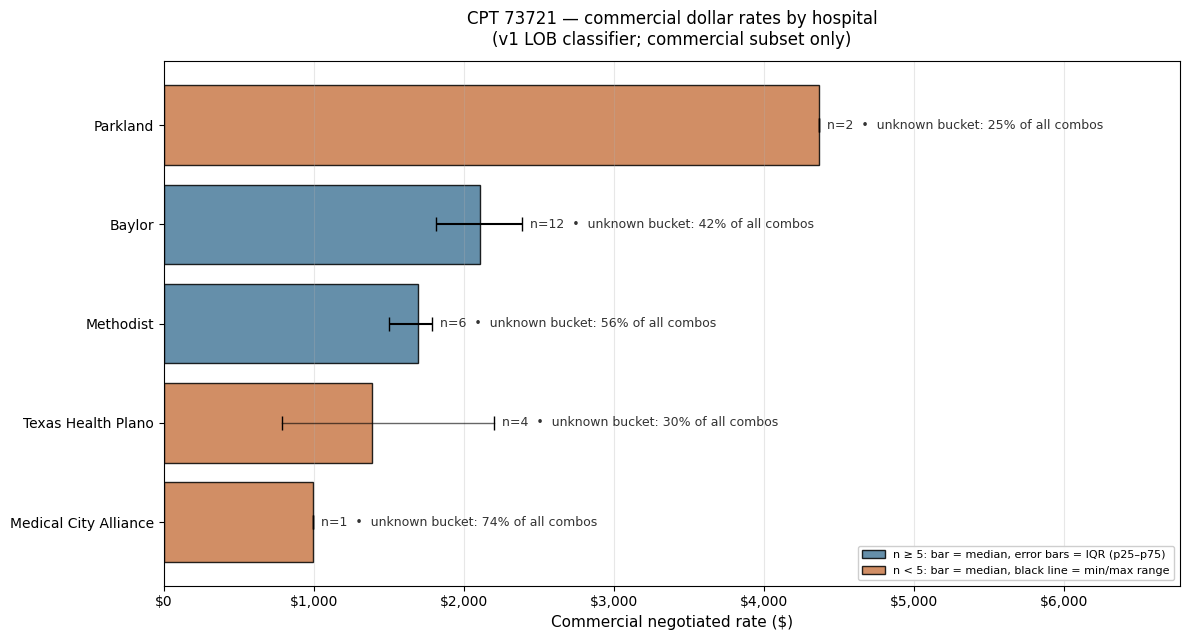

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch

# Rebuild summary (same logic as before)
rows = []
for h in dfs.keys():
    df = dfs[h]
    comm = df[df['lob'] == 'commercial']
    comm_dollar = comm[comm['dollar_rate'].notna()]
    n_dollar = len(comm_dollar)
    n_unknown = (df['lob'] == 'unknown').sum()
    n_total = len(df)
    if n_dollar == 0:
        rows.append({'hospital': h, 'median': None, 'p25': None, 'p75': None,
                     'rate_min': None, 'rate_max': None, 'n_dollar': 0,
                     'n_unknown': n_unknown, 'n_total': n_total})
        continue
    rows.append({
        'hospital': h,
        'median':   comm_dollar['dollar_rate'].median(),
        'p25':      comm_dollar['dollar_rate'].quantile(0.25),
        'p75':      comm_dollar['dollar_rate'].quantile(0.75),
        'rate_min': comm_dollar['dollar_rate'].min(),
        'rate_max': comm_dollar['dollar_rate'].max(),
        'n_dollar': n_dollar,
        'n_unknown': n_unknown,
        'n_total':  n_total,
    })

# Sort ascending — smallest median at top of y-axis (barh plots index 0 at bottom by default,
# so we want largest at the END of the list to appear at the top)
summary = pd.DataFrame(rows).sort_values('median', ascending=True, na_position='first').reset_index(drop=True)

# Chart
fig, ax = plt.subplots(figsize=(12, 6.5))
y_pos = np.arange(len(summary))

BLUE = '#4a7c9b'
ORANGE = '#c97a4a'

for i, row in summary.iterrows():
    if row['n_dollar'] == 0:
        continue
    med = row['median']
    if row['n_dollar'] >= 5:
        err_low = med - row['p25']
        err_high = row['p75'] - med
        ax.barh(i, med, xerr=[[err_low], [err_high]],
                color=BLUE, edgecolor='black', capsize=5, alpha=0.85)
    else:
        ax.barh(i, med, color=ORANGE, edgecolor='black', alpha=0.85)
        # Min/max line + end caps
        ax.plot([row['rate_min'], row['rate_max']], [i, i],
                color='black', linewidth=1, alpha=0.6)
        ax.plot([row['rate_min'], row['rate_max']], [i, i],
                marker='|', color='black', markersize=10, linestyle='none')

ax.set_yticks(y_pos)
ax.set_yticklabels([h.replace('_', ' ').title() for h in summary['hospital']])
ax.set_xlabel('Commercial negotiated rate ($)', fontsize=11)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='x', alpha=0.3)

# Give x-axis headroom on right so right-side annotations don't clip
x_max = summary['median'].max() if summary['median'].notna().any() else 0
ax.set_xlim(0, x_max * 1.55)

# Annotate to the RIGHT of each bar's end (not over it), positioned past max of bar/error
for i, row in summary.iterrows():
    if row['n_dollar'] == 0:
        continue
    # Right edge of either the IQR bar or min/max line — whichever is larger
    if row['n_dollar'] >= 5:
        right_edge = row['p75']
    else:
        right_edge = row['rate_max']
    unk_pct = row['n_unknown'] / row['n_total'] * 100
    label = f"  n={int(row['n_dollar'])}  •  unknown bucket: {unk_pct:.0f}% of all combos"
    ax.text(right_edge, i, label, va='center', fontsize=9, color='#333')

# Title — single line, no overlapping subtitle
ax.set_title('CPT 73721 — commercial dollar rates by hospital\n(v1 LOB classifier; commercial subset only)',
             fontsize=12, pad=12)

# Legend for bar colors — explains blue vs orange
legend_handles = [
    Patch(facecolor=BLUE, edgecolor='black', alpha=0.85, label='n ≥ 5: bar = median, error bars = IQR (p25–p75)'),
    Patch(facecolor=ORANGE, edgecolor='black', alpha=0.85, label='n < 5: bar = median, black line = min/max range'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8, framealpha=0.95)

plt.tight_layout()
plt.savefig('../outputs/day6_commercial_dollar_rates_cpt73721.png', dpi=150, bbox_inches='tight')
plt.show()

Commercial methodology mix per hospital (CPT 73721):

             hospital  n_comm  dollar_only_n  pct_only_n  both_n  neither_n  dollar_only_pct  pct_only_pct  both_pct  neither_pct
medical_city_alliance       2              1           1       0          0             50.0          50.0       0.0          0.0
   texas_health_plano       5              4           1       0          0             80.0          20.0       0.0          0.0
            methodist       6              6           0       0          0            100.0           0.0       0.0          0.0
               baylor      12             12           0       0          0            100.0           0.0       0.0          0.0
             parkland       3              0           0       2          1              0.0           0.0      66.7         33.3


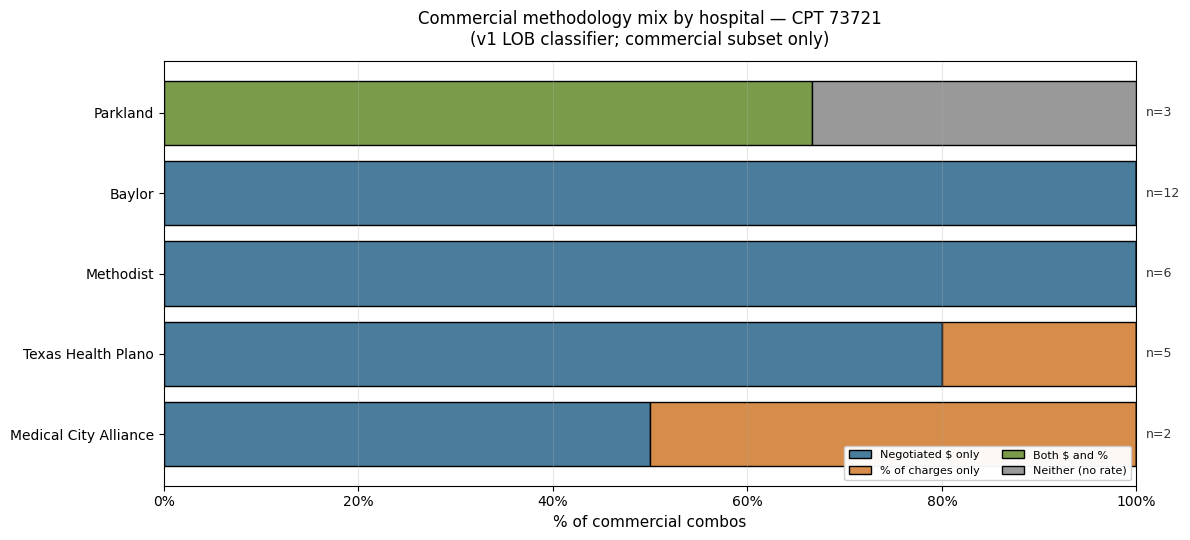

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch

# Build commercial-only methodology mix per hospital
method_rows = []
for h in dfs.keys():
    df = dfs[h]
    comm = df[df['lob'] == 'commercial']
    n_comm = len(comm)
    if n_comm == 0:
        method_rows.append({
            'hospital': h, 'n_comm': 0,
            'dollar_only_pct': 0, 'pct_only_pct': 0, 'both_pct': 0, 'neither_pct': 0,
            'dollar_only_n': 0, 'pct_only_n': 0, 'both_n': 0, 'neither_n': 0,
        })
        continue
    has_dollar = comm['dollar_rate'].notna()
    has_pct = comm['pct_rate'].notna()
    n_dollar_only = (has_dollar & ~has_pct).sum()
    n_pct_only = (~has_dollar & has_pct).sum()
    n_both = (has_dollar & has_pct).sum()
    n_neither = (~has_dollar & ~has_pct).sum()
    method_rows.append({
        'hospital': h, 'n_comm': n_comm,
        'dollar_only_pct': n_dollar_only / n_comm * 100,
        'pct_only_pct':    n_pct_only / n_comm * 100,
        'both_pct':        n_both / n_comm * 100,
        'neither_pct':     n_neither / n_comm * 100,
        'dollar_only_n': n_dollar_only, 'pct_only_n': n_pct_only,
        'both_n': n_both, 'neither_n': n_neither,
    })

method_df = pd.DataFrame(method_rows)

# Match chart 1's hospital order (ascending by chart 1's median)
method_df['hospital'] = pd.Categorical(method_df['hospital'],
                                       categories=summary['hospital'].tolist(),
                                       ordered=True)
method_df = method_df.sort_values('hospital').reset_index(drop=True)

print("Commercial methodology mix per hospital (CPT 73721):\n")
print(method_df[['hospital', 'n_comm',
                 'dollar_only_n', 'pct_only_n', 'both_n', 'neither_n',
                 'dollar_only_pct', 'pct_only_pct', 'both_pct', 'neither_pct']]
      .round(1).to_string(index=False))

# Chart 2 — stacked horizontal bars
fig, ax = plt.subplots(figsize=(12, 5.5))
y_pos = np.arange(len(method_df))

DOLLAR_COLOR  = '#4a7c9b'   # blue — same as IQR chart, consistency
PCT_COLOR     = '#d68c4a'   # orange
BOTH_COLOR    = '#7a9b4a'   # green
NEITHER_COLOR = '#999999'   # grey

dollar = method_df['dollar_only_pct'].values
pct    = method_df['pct_only_pct'].values
both   = method_df['both_pct'].values
neither = method_df['neither_pct'].values

ax.barh(y_pos, dollar, color=DOLLAR_COLOR, edgecolor='black',
        label='Negotiated $ only')
ax.barh(y_pos, pct, left=dollar, color=PCT_COLOR, edgecolor='black',
        label='% of charges only')
ax.barh(y_pos, both, left=dollar+pct, color=BOTH_COLOR, edgecolor='black',
        label='Both $ and %')
if neither.sum() > 0:
    ax.barh(y_pos, neither, left=dollar+pct+both, color=NEITHER_COLOR,
            edgecolor='black', label='Neither (no rate)')

ax.set_yticks(y_pos)
ax.set_yticklabels([h.replace('_', ' ').title() for h in method_df['hospital']])
ax.set_xlabel('% of commercial combos', fontsize=11)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlim(0, 100)
ax.grid(axis='x', alpha=0.3)

# Annotate combo count on right, outside the 0–100 bar area
for i, n in enumerate(method_df['n_comm']):
    ax.text(101, i, f'n={int(n)}', va='center', fontsize=9, color='#333')

ax.set_title('Commercial methodology mix by hospital — CPT 73721\n'
             '(v1 LOB classifier; commercial subset only)',
             fontsize=12, pad=12)

ax.legend(loc='lower right', fontsize=8, framealpha=0.95, ncol=2)

plt.tight_layout()
plt.savefig('../outputs/day6_commercial_methodology_mix_cpt73721.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Thursday's "Parkland 54% percent-of-charges" figure — corrected
# ============================================================

parkland_row = method_df[method_df['hospital'] == 'parkland'].iloc[0]
n = int(parkland_row['n_comm'])

print("Parkland — CPT 73721 outpatient, commercial only:")
print(f"  Total commercial combos:  {n}")
print()
print(f"  Negotiated $ only:        {int(parkland_row['dollar_only_n'])}  ({parkland_row['dollar_only_pct']:.1f}%)")
print(f"  % of charges only:        {int(parkland_row['pct_only_n'])}  ({parkland_row['pct_only_pct']:.1f}%)")
print(f"  Both $ and %:             {int(parkland_row['both_n'])}  ({parkland_row['both_pct']:.1f}%)")
print(f"  Neither:                  {int(parkland_row['neither_n'])}  ({parkland_row['neither_pct']:.1f}%)")
print()
pct_any = parkland_row['pct_only_pct'] + parkland_row['both_pct']
print(f"  Any percentage methodology (% only + both): {pct_any:.1f}%")
print()
print("Thursday's '54%' figure used:")
print("  - a non-commercial denominator (mislabeled CHIP/STAR/Medicare Advantage/ACA included)")
print("  - mutually-exclusive bucket math on overlapping populations")
print(f"  Corrected commercial-only figure: {pct_any:.1f}% of Parkland's {n} commercial combos use any percentage methodology")

Parkland — CPT 73721 outpatient, commercial only:
  Total commercial combos:  3

  Negotiated $ only:        0  (0.0%)
  % of charges only:        0  (0.0%)
  Both $ and %:             2  (66.7%)
  Neither:                  1  (33.3%)

  Any percentage methodology (% only + both): 66.7%

Thursday's '54%' figure used:
  - a non-commercial denominator (mislabeled CHIP/STAR/Medicare Advantage/ACA included)
  - mutually-exclusive bucket math on overlapping populations
  Corrected commercial-only figure: 66.7% of Parkland's 3 commercial combos use any percentage methodology


In [ ]:
parkland = dfs['parkland']
neither = parkland[
    (parkland['lob'] == 'commercial') &
    parkland['dollar_rate'].isna() &
    parkland['pct_rate'].isna()
]
print(f"Parkland commercial-neither combos: {len(neither)}")
print()
cols = ['payer_name', 'plan_name', 'methodology_normalized', 
        'billing_class_normalized', 'n_charge_ids', 'gross_min', 'gross_max']
print(neither[cols].to_string(index=False))

Parkland commercial-neither combos: 1

                           payer_name                         plan_name methodology_normalized billing_class_normalized  n_charge_ids  gross_min  gross_max
DELTA DENTAL INSURANCE COMPANY [1150] DELTA DENTAL PPO/PREMIER [115001]                  other                 facility             8     6067.0    12131.0
